# IMPORT

In [8]:
from pathlib import Path
from PIL import Image
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# LOAD DATA

load data from [kaggle](https://www.kaggle.com/datasets/jonathanoheix/face-expression-recognition-dataset)

In [31]:
data_path = Path("./data/faces/images/images/")

classes = ["happy", "sad"]

images = []
labels = []

for label in classes:
    folder = data_path / label

    for file in list(folder.iterdir())[:2000]:
        image = Image.open(file).convert("L")

        image = np.array(image)

        images.append(image.flatten())
        labels.append(label)

X = np.array(images)
y = np.array(labels)

print(X.shape)

(4000, 2304)


# PCA

In [41]:
pca = PCA(
    n_components=500
)

Z = pca.fit_transform(X)

print(Z.shape)

(4000, 500)


representation of emotion

In [42]:
happy_mean = Z[y == "happy"].mean(axis=0)
sad_mean = Z[y == "sad"].mean(axis=0)

emotion_direction = happy_mean - sad_mean

Facial Expression Transformation with PCA

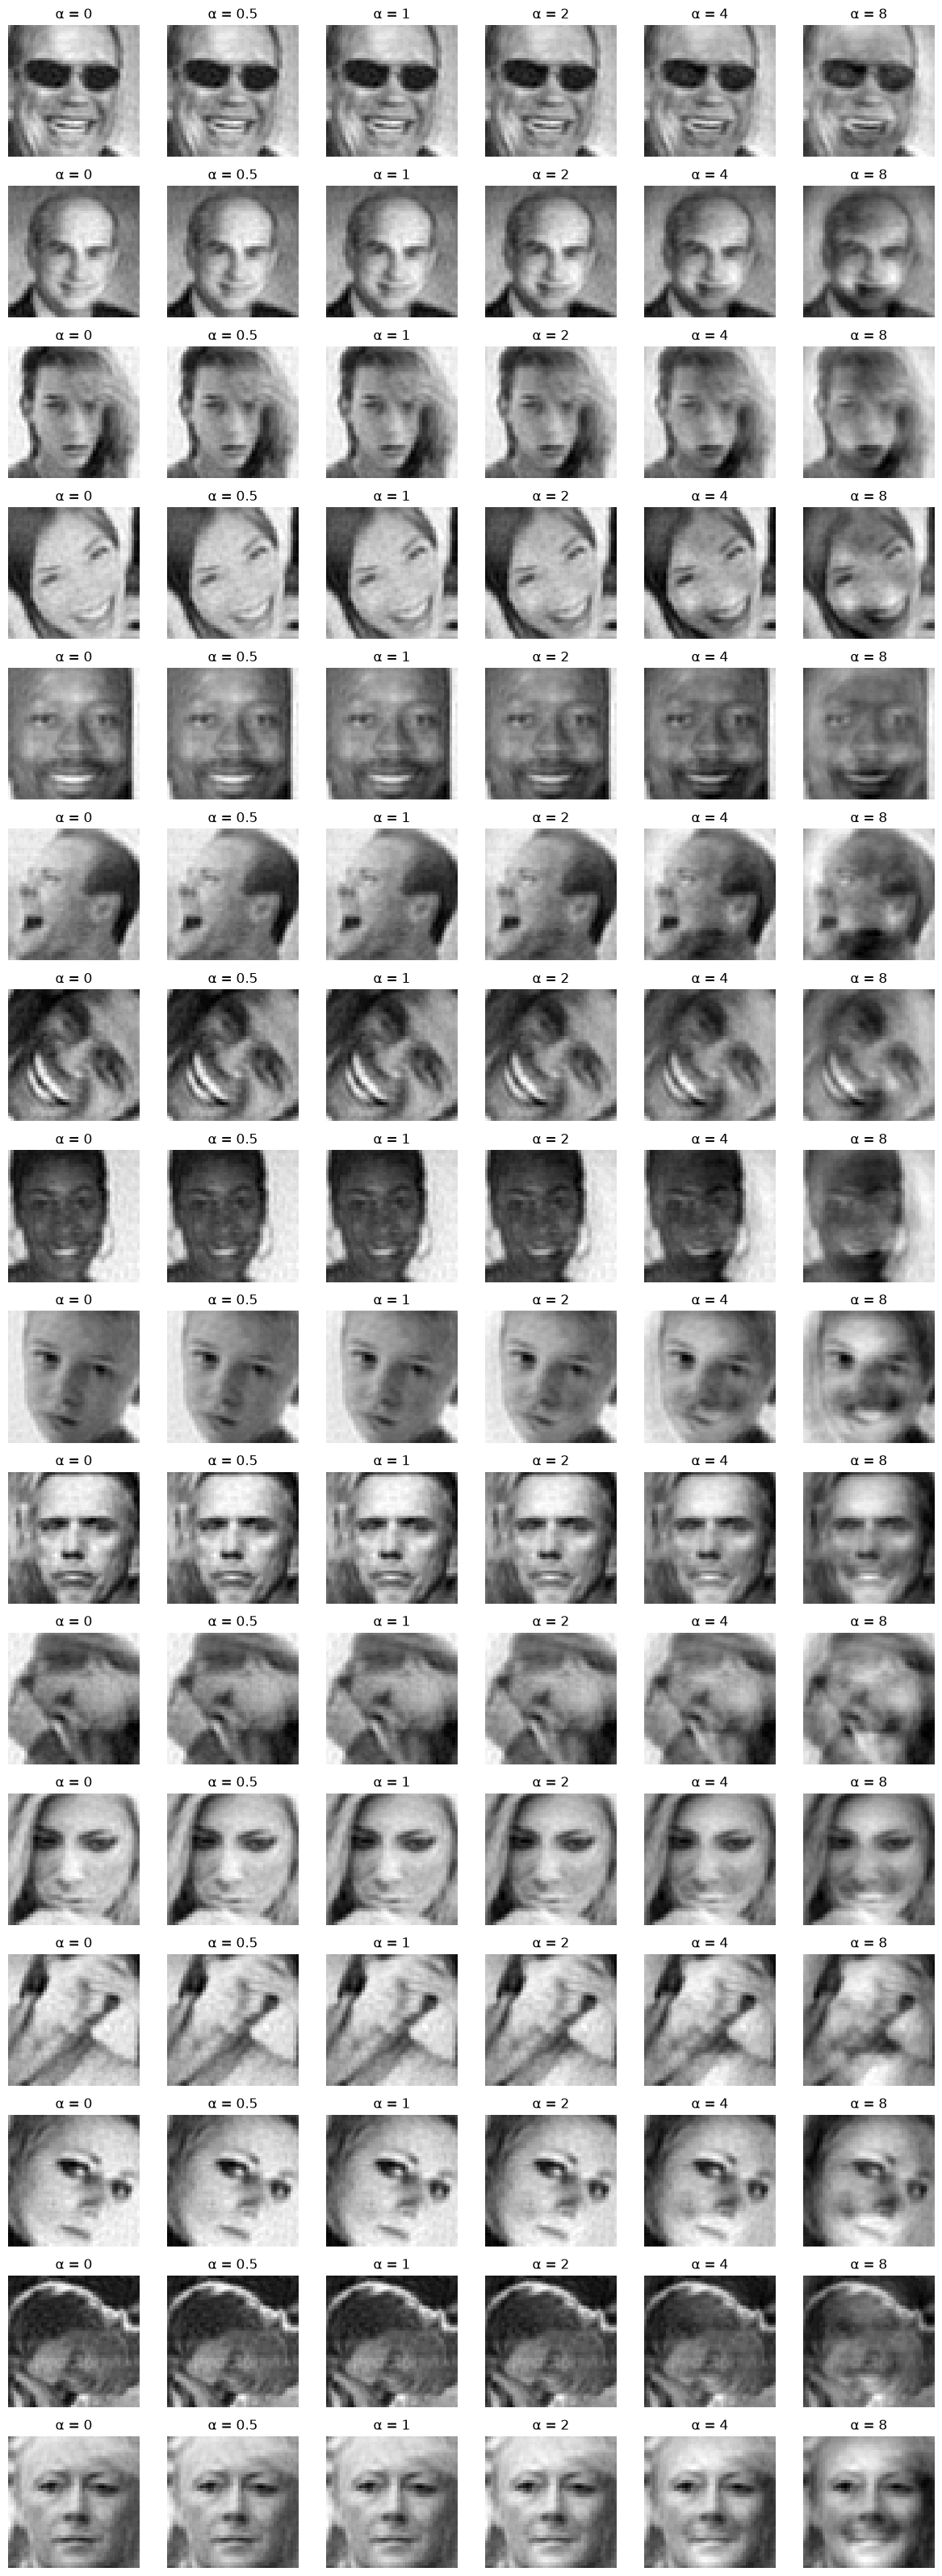

In [43]:
alphas = [0, 0.5, 1, 2, 4, 8]

happy_indices = np.where(y == "happy")[0][:8]
sad_indices = np.where(y == "sad")[0][:8]

fig, axes = plt.subplots(16, 6, figsize=(12, 32))

# Happy → Sad
for row, index in enumerate(happy_indices):

    z_happy = Z[index].reshape(1, -1)

    for ax, alpha in zip(axes[row], alphas):

        z_modified = z_happy - alpha * emotion_direction

        image_modified = pca.inverse_transform(z_modified)[0]
        image_modified = image_modified.reshape(image.shape)

        ax.imshow(image_modified, cmap="gray")
        ax.set_title(f"α = {alpha}")
        ax.axis("off")


# Sad → Happy
for row, index in enumerate(sad_indices, start=8):

    z_sad = Z[index].reshape(1, -1)

    for ax, alpha in zip(axes[row], alphas):

        z_modified = z_sad + alpha * emotion_direction

        image_modified = pca.inverse_transform(z_modified)[0]
        image_modified = image_modified.reshape(image.shape)

        ax.imshow(image_modified, cmap="gray")
        ax.set_title(f"α = {alpha}")
        ax.axis("off")


plt.tight_layout()
plt.show()

The PCA representation allows gradual modification of facial expressions by moving along the direction from sad to happy faces and vice versa. The effect becomes more noticeable as $\alpha$ increases, although large values introduce significant image distortions. Overall, PCA can partially transform facial expressions, but the results are limited by the linear nature of the representation.